<a href="https://colab.research.google.com/github/whtan88/RandomDataAnalyst_Projects/blob/main/XGB_Classifier_StockIndex_Predictor_EDA_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Resolving Dependency Conflicts for `pandas_ta`

As explained, installing `pandas_ta` directly often leads to dependency conflicts because it requires newer versions of `numpy` and `pandas` than those compatible with other pre-installed Colab libraries (like `scikit-learn` and `google-colab`). The `ImportError` you saw for `_center` from `numpy._core.umath` is a symptom of `scikit-learn` being incompatible with `numpy 2.x`.

To fix this, we will:
1.  Uninstall the potentially problematic versions of `pandas_ta`, `numpy`, and `pandas`.
2.  Explicitly install `numpy==1.26.4` and `pandas==2.2.2`, which are known to be compatible with the Colab environment's core libraries.
3.  Install `pandas_ta` using the `--no-deps` flag to prevent it from upgrading `numpy` and `pandas` again.
4.  **Crucially, you must restart your Colab runtime after running these cells for the changes to take effect.**

In [ ]:
# 1. Uninstall pandas_ta, numpy, and pandas to clean the environment.
!pip uninstall -y pandas_ta numpy pandas numba llvmlite

# 2. Install numpy, pandas, numba, and llvmlite versions compatible with Colab's pre-installed libraries.
# numpy 1.26.4 and pandas 2.2.2 are generally stable for Colab environments.
# numba 0.61.2 and llvmlite 0.44.0 are known to work with pandas_ta and potentially with numpy 1.x.
!pip install numpy==1.26.4 pandas==2.2.2 numba==0.61.2 llvmlite==0.44.0

# 3. Install pandas_ta, but prevent it from upgrading numpy, pandas, numba, or llvmlite again.
# Note: pandas_ta officially requires numpy>=2.2.6. If this version of pandas_ta
# does not work with numpy 1.x, you might need to find an older version of pandas_ta.
!pip install pandas_ta --no-deps

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
Found existing installation: numba 0.60.0
Uninstalling numba-0.60.0:
  Successfully uninstalled numba-0.60.0
Found existing installation: llvmlite 0.43.0
Uninstalling llvmlite-0.43.0:
  Successfully uninstalled llvmlite-0.43.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 12.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 2.0 MB/s eta 0:00:00


## Action Required: Re-run Installation and Restart Runtime

It appears the installation of `pandas_ta` in the previous step was interrupted. Please **re-run the `!pip install pandas_ta --no-deps` command** (cell above this one) to ensure `pandas_ta` is installed correctly.

After re-running the installation, please **restart your Colab runtime** again (Runtime -> Restart runtime...) for these changes to take full effect. After restarting, you should be able to run your code without the `ImportError` or `ModuleNotFoundError`.

In [ ]:
# Import libraries
import pandas_ta as ta

import re
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from datetime import datetime,timedelta
from sklearn.preprocessing import StandardScaler # This should now work
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


import xgboost as xgb
from xgboost import XGBClassifier
from scipy.stats import uniform, randint

from sklearn.model_selection import RandomizedSearchCV
from sklearn.calibration import CalibratedClassifierCV, calibration_curve, CalibrationDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

# Usual Data Processing

In [ ]:
# Function
def feature_engineering_1(df,ticker):
  # Insert Feature engineering here
  return df

def feature_engineering_2(df, ticker):
  # Insert Feature engineering here
  return df

def prep_data(ticker, start_date, test_start_date, current_date,label='binary'):

  def flatten_multiindex_columns(df_to_flatten):
      new_columns = []
      for col in df_to_flatten.columns:
          if isinstance(col, tuple):
              clean_parts = [str(part) for part in col if str(part).strip()]
              if clean_parts:
                  new_columns.append('_'.join(clean_parts))
              else:
                  if len(col) > 0 and str(col[0]).strip():
                      new_columns.append(str(col[0]))
                  else:
                      new_columns.append('_'.join(map(str, col)))
          else:
              new_columns.append(str(col))
      df_to_flatten.columns = new_columns
      return df_to_flatten

  df = yf.download(ticker, start=start_date, end=current_date, interval='1d', auto_adjust=True).reset_index()
  df = df.sort_index()
  df = feature_engineering_1(df,ticker)
  df = feature_engineering_2(df,ticker)

  # Drop rows with NaN values after feature engineering but before splitting
  #df.dropna(inplace=True)

  # Flatten columns after feature engineering
  df = flatten_multiindex_columns(df)

  # Corrected list_drop to match the actual DataFrame column names
  list_drop = [('Date',''), ('Close', ticker), ('High', ticker), ('Low', ticker), ('Open', ticker), ('Volume',ticker), 'cat_close', \
   ('SMA_5',''), ('SMA_10',''), ('SMA_20',''), ('EMA_5',''), ('EMA_10',''), ('EMA_20','')]

  # Reconstruct list_drop with flattened names
  list_drop_flattened = []
  for item in list_drop:
      if isinstance(item, tuple):
          clean_parts = [str(part) for part in item if str(part).strip()]
          if clean_parts:
              list_drop_flattened.append('_'.join(clean_parts))
          else:
              if len(item) > 0 and str(item[0]).strip():
                  list_drop_flattened.append(str(item[0]))
              else:
                  list_drop_flattened.append('_'.join(map(str, item)))
      else:
          list_drop_flattened.append(str(item))

  # Split dataframes based on the cleaned df
  # Use flattened column names
  df_train_raw = df[df['Date'] < test_start_date].copy()
  df_test_raw = df[df['Date'] >= test_start_date][:-1].copy() # Exclude the very last row for prediction
  df_predict_raw = df.iloc[-1:].copy()

  #print(df_test_raw['Date']) # Use flattened column name

  # Prepare target labels y_train and y_test from 'cat_close' before it's dropped from features
  y_train = df_train_raw['cat_close']
  y_test = df_test_raw['cat_close']

  # Extract the list of dates
  test_date = df_test_raw['Date']
  list_date = df_predict_raw['Date']

  # Drop non-feature columns from the dataframes BEFORE scaling
  # Use the flattened list_drop
  df_train = df_train_raw.drop(columns=list_drop_flattened)
  df_test = df_test_raw.drop(columns=list_drop_flattened)
  df_predict = df_predict_raw.drop(columns=list_drop_flattened)

  scaler = StandardScaler()

  # Apply scaler to the processed dataframes
  df_train_scaled = scaler.fit_transform(df_train)
  df_train = pd.DataFrame(df_train_scaled, columns=df_train.columns, index=df_train.index)

  df_test_scaled = scaler.transform(df_test) # Use transform, not fit_transform for test data
  df_test = pd.DataFrame(df_test_scaled, columns=df_test.columns, index=df_test.index)

  df_predict_scaled = scaler.transform(df_predict)
  df_predict = pd.DataFrame(df_predict_scaled, columns=df_predict.columns, index=df_predict.index)

  return df_train, y_train, df_test, y_test, df_predict, test_date, list_date


In [ ]:
# Feature Engineering and data processing pipeline

ticker = '^SPX'
start_date = '2020-01-01'
test_start_date = '2026-01-01'
current_date = '2026-06-30'
#current_date = datetime.now().date()
label = 'binary'

X_train, y_train, X_test, y_test, df_predict, test_date, list_date = prep_data(ticker, start_date, test_start_date, current_date, label)
X_train.head()

[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2541/1032760582.py:7: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(columns=['day']) # Drop the original 'day' column
/tmp/ipykernel_2541/1032760582.py:11: PerformanceWarning: indexing past lexsort depth may impact performance.
  df['month'] = df[('Date',)].dt.month
/tmp/ipykernel_2541/1032760582.py:116: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'bb_{j}_period_{i}_std_open_to_lower'] = (df[('Open', ticker)] - df['bb_lower_band'])/df[f'SMA_{j}']
/tmp/ipykernel_2541/1032760582.py:117: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` ma

,day_Monday,day_Thursday,day_Tuesday,day_Wednesday,month,sin_month,cos_month,ratio close to high T0,ratio close to low T0,ratio close to open T0,...,Bearish Marubozu T-2,Spinning_Tops_Doji T0,Spinning_Tops_Doji T-1,Spinning_Tops_Doji T-2,Bullish Hammer T0,Bearish Shooting Star T0,Bullish Harami T0,Bearish Harami T0,Bullish Engulfing T0,Bearish Engulfing T0
0,-0.478554,1.994216,-0.510754,-0.508689,-1.618359,0.719365,1.236998,0.793218,0.015914,0.382086,...,-4.566735,-0.333579,-0.333579,-0.535434,-0.340896,-0.349319,-0.109911,0.0,-0.063203,-0.149576
1,-0.478554,-0.501450,-0.510754,-0.508689,-1.618359,0.719365,1.236998,0.326362,-0.388823,0.239442,...,-4.566735,-0.333579,-0.333579,-0.535434,-0.340896,-0.349319,-0.109911,0.0,-0.063203,-0.149576
2,2.089629,-0.501450,-0.510754,-0.508689,-1.618359,0.719365,1.236998,0.781719,0.410980,0.867357,...,0.218975,-0.333579,-0.333579,-0.535434,-0.340896,-0.349319,-0.109911,0.0,-0.063203,-0.149576
3,-0.478554,-0.501450,1.957890,-0.508689,-1.618359,0.719365,1.236998,0.477593,-0.712595,-0.166869,...,0.218975,-0.333579,-0.333579,-0.535434,-0.340896,-0.349319,-0.109911,0.0,-0.063203,-0.149576
4,-0.478554,-0.501450,-0.510754,1.965837,-1.618359,0.719365,1.236998,0.214835,-0.230677,0.422247,...,0.218975,-0.333579,-0.333579,-0.535434,-0.340896,-0.349319,-0.109911,0.0,-0.063203,-0.149576


# Assess Model Performance

In [ ]:
# Train XGB Classifier model

model = XGBClassifier(random_state=42
#    n_estimators=100, learning_rate=0.1, max_depth=5,random_state=42
)

# Fit the model
model.fit(X_train, y_train)

# Make train predictions
predictions = model.predict(X_test)
predicted_proba = model.predict_proba(X_test)[:, 1]

t = 0.005
print('---Test Data---')
print(y_test.value_counts())
print(f'Accuracy Score : {accuracy_score(y_test, predictions)}')
print(f'Precision Score : {precision_score(y_test, predictions, average='macro')}')
print(f'Recall Score : {recall_score(y_test, predictions, average='macro')}')
print('--- Confusion Matrix ---')
print(confusion_matrix(y_test, predictions))
print('--- Classification Report ---')
print(classification_report(y_test, predictions, target_names=["Down", "Up"]))


---Test Data---
cat_close
1    66
0    55
Name: count, dtype: int64
Accuracy Score : 0.5371900826446281
Precision Score : 0.5251524390243902
Recall Score : 0.5227272727272727
--- Confusion Matrix ---
[[20 35]
 [21 45]]
--- Classification Report ---
              precision    recall  f1-score   support

        Down       0.49      0.36      0.42        55
          Up       0.56      0.68      0.62        66

    accuracy                           0.54       121
   macro avg       0.53      0.52      0.52       121
weighted avg       0.53      0.54      0.53       121



In [ ]:
# Create another dataframe based on test date range

df_test_orig = yf.download(ticker, start= '2025-12-01', end='2026-06-30', interval='1d', auto_adjust=True).reset_index()
df_test_orig['ATR T0'] = ta.atr(df_test_orig[('High', ticker)], df_test_orig[('Low', ticker)], df_test_orig[('Close', ticker)])
df_test_orig = df_test_orig[df_test_orig['Date'] >= '2026-01-01'].iloc[1:].copy()
df_test_orig['predicted_direction'] = predictions
df_test_orig['actual_direction'] = list(y_test)
df_test_orig.head(10)

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume,ATR T0,predicted_direction,actual_direction
Ticker,,^SPX,^SPX,^SPX,^SPX,^SPX,,,
23,2026-01-05,6902.049805,6920.379883,6891.560059,6892.189941,5771930000,53.541006,0,1
24,2026-01-06,6944.819824,6948.689941,6904.020020,6908.029785,5509680000,53.048087,1,1
25,2026-01-07,6920.930176,6965.689941,6919.189941,6945.069824,5214480000,52.580367,1,0
26,2026-01-08,6921.459961,6931.279785,6899.330078,6914.109863,5333200000,51.106748,1,1
27,2026-01-09,6966.279785,6978.359863,6917.640137,6927.830078,5163900000,51.793389,1,1
28,2026-01-12,6977.270020,6986.330078,6934.069824,6944.120117,5019040000,51.826737,1,1
29,2026-01-13,6963.740234,6985.830078,6938.770020,6977.410156,5091730000,51.486260,1,0
30,2026-01-14,6926.600098,6941.299805,6885.740234,6937.410156,5530830000,53.380098,0,0
31,2026-01-15,6944.470215,6979.339844,6937.930176,6969.459961,5114050000,53.334359,1,1


In [ ]:
# Assess ATR ranges
df_test_orig['ATR T0'].describe()

,ATR T0
count,121.000000
mean,81.425282
std,14.815080
min,51.106748
25%,74.760226
50%,80.436755
75%,95.167694
max,106.030098


In [ ]:
# Create function to calculate PnL on each trade based on model predicted direction

def calculate_portfolio_returns(df):
  df['buy_strategy'] = np.where((df['predicted_direction'] == 1), 'bull put spread', 'bear call spread')
  df['entry_level'] = np.where(df['buy_strategy'] == 'bull put spread', (df[('Open', ticker)] - 20) // 5 * 5, 0)
  df['entry_level'] = np.where(df['buy_strategy'] == 'bear call spread', (df[('Open', ticker)] + 20) // 5 * 5, df['entry_level'])

  df['trade_PnL'] = np.where((df['buy_strategy'] == 'bull put spread') & (df['entry_level'] <= (df[('Close', ticker)])), 50, 0)
  df['trade_PnL'] = np.where((df['buy_strategy'] == 'bull put spread') & (df['entry_level'] > (df[('Close', ticker)])), -400, df['trade_PnL'])
  df['trade_PnL'] = np.where((df['buy_strategy'] == 'bear call spread') & (df['entry_level'] >= (df[('Close', ticker)])), 50, df['trade_PnL'])
  df['trade_PnL'] = np.where((df['buy_strategy'] == 'bear call spread') & (df['entry_level'] < (df[('Close', ticker)])), -400, df['trade_PnL'])

  df['cumulative_PnL'] = df['trade_PnL'].cumsum()

  return df
df_portfolio = calculate_portfolio_returns(df_test_orig)
df_portfolio.tail()

Price,Date,Close,High,Low,Open,Volume,ATR T0,predicted_direction,actual_direction,buy_strategy,entry_level,trade_PnL,cumulative_PnL
Ticker,,^SPX,^SPX,^SPX,^SPX,^SPX,,,,,,,
139,2026-06-23,7365.459961,7424.169922,7347.600098,7366.509766,5640530000,98.760525,1,0,bull put spread,7345.0,50,-12150
140,2026-06-24,7358.220215,7428.060059,7336.819824,7370.879883,5994860000,98.223362,0,0,bear call spread,7390.0,50,-12100
141,2026-06-25,7357.490234,7419.080078,7323.500000,7404.910156,5565760000,98.034556,1,0,bull put spread,7380.0,-400,-12500
142,2026-06-26,7354.020020,7392.950195,7294.180176,7312.740234,9105600000,98.087089,0,0,bear call spread,7330.0,-400,-12900
143,2026-06-29,7440.430176,7444.319824,7348.879883,7391.879883,5794570000,97.898007,1,1,bull put spread,7370.0,50,-12850


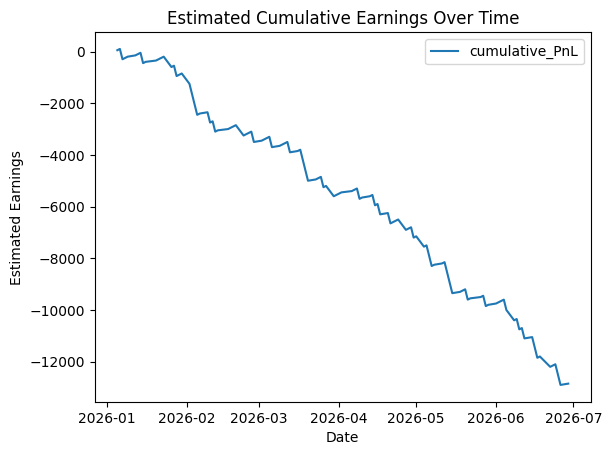

In [ ]:
# Plot Estimated Cumulative Earnings

sns.lineplot(x=df_portfolio['Date'], y=df_portfolio['cumulative_PnL'], label='cumulative_PnL')
plt.ylabel('Estimated Earnings')
plt.title("Estimated Cumulative Earnings Over Time")
plt.show()

In [ ]:
# Check the PnL stats of the directional moves
df_portfolio[['buy_strategy','trade_PnL']].groupby('buy_strategy').sum().reset_index()

Price,buy_strategy,trade_PnL
Ticker,,
0,bear call spread,-5150
1,bull put spread,-7700


# What if we perform some hyperparameter tuning?

In [ ]:
# Define the parameter search space
# Using statistical distributions ensures smooth random sampling across bounds
param_dist = {
    "n_estimators": randint(100, 1000),         # Number of trees
    "learning_rate": uniform(0.01, 0.25),        # Step size shrinkage
    "max_depth": randint(3, 10),                 # Tree depth complexity
    "min_child_weight": randint(1, 10),          # Noise control
    "subsample": uniform(0.6, 0.4),              # Row fraction sampling (0.6 to 1.0)
    "colsample_bytree": uniform(0.6, 0.4),       # Feature fraction sampling (0.6 to 1.0)
    "gamma": uniform(0, 5)                       # Split threshold penalty
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,                  # Number of random combinations evaluated
    scoring="accuracy",          # Metric to optimize
    verbose=1,
    random_state=42,
    n_jobs=-1,
    return_train_score=False
)

# 5. Execute the search
print("Starting hyperparameter tuning space search...")
random_search.fit(X_train, y_train)

# 6. Extract winning configurations
print(f"\nBest Score: {random_search.best_score_:.4f}")
print("Best Parameters Discovered:")
for param_name, param_value in random_search.best_params_.items():
    print(f" -> {param_name}: {param_value}")

# Fetching the optimized model directly
xgb_rscv = random_search.best_estimator_

Starting hyperparameter tuning space search...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Score: 0.4987
Best Parameters Discovered:
 -> colsample_bytree: 0.8550229885420852
 -> gamma: 4.436063712881633
 -> learning_rate: 0.12805373129048733
 -> max_depth: 7
 -> min_child_weight: 3
 -> n_estimators: 868
 -> subsample: 0.8886918084659492


In [ ]:
print(random_search.best_params_)

{'colsample_bytree': 0.8550229885420852, 'gamma': 4.436063712881633, 'learning_rate': 0.12805373129048733, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 868, 'subsample': 0.8886918084659492}


In [ ]:
# Train XGB with random search CV parameters
rscv_params = {'colsample_bytree': 0.8550229885420852, 'gamma': 4.436063712881633, 'learning_rate': 0.12805373129048733, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 868, 'subsample': 0.8886918084659492}
xgb_rscv = XGBClassifier(**rscv_params)
xgb_rscv.fit(X_train, y_train)

# Make train predictions
rscv_predictions = xgb_rscv.predict(X_test)
rscv_predicted_proba = xgb_rscv.predict_proba(X_test)[:, 1]

t = 0.005
print('---Test Data---')
print(f'Accuracy Score : {accuracy_score(y_test, rscv_predictions)}')
print(f'Precision Score : {precision_score(y_test, rscv_predictions, average='macro')}')
print(f'Recall Score : {recall_score(y_test, rscv_predictions, average='macro')}')
print('--- Confusion Matrix ---')
print(confusion_matrix(y_test, rscv_predictions))
print('--- Classification Report ---')
print(classification_report(y_test, rscv_predictions, target_names=["Down", "Up"]))


---Test Data---
Accuracy Score : 0.5041322314049587
Precision Score : 0.4817275747508305
Recall Score : 0.48484848484848486
--- Confusion Matrix ---
[[15 40]
 [20 46]]
--- Classification Report ---
              precision    recall  f1-score   support

        Down       0.43      0.27      0.33        55
          Up       0.53      0.70      0.61        66

    accuracy                           0.50       121
   macro avg       0.48      0.48      0.47       121
weighted avg       0.49      0.50      0.48       121



In [ ]:
# Create new dataframe to measure PnL for tuned model with Random Search CV

df_test_orig_rscv = yf.download(ticker, start= '2025-12-01', end='2026-06-30', interval='1d', auto_adjust=True).reset_index()
df_test_orig_rscv = df_test_orig_rscv[df_test_orig_rscv['Date'] >= '2026-01-01'].iloc[1:].copy()
df_test_orig_rscv['predicted_direction'] = rscv_predictions
df_test_orig_rscv['actual_direction'] = list(y_test)
df_portfolio_rscv = calculate_portfolio_returns(df_test_orig_rscv)
df_portfolio_rscv.tail()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume,predicted_direction,actual_direction,buy_strategy,entry_level,trade_PnL,cumulative_PnL
Ticker,,^SPX,^SPX,^SPX,^SPX,^SPX,,,,,,
139,2026-06-23,7365.459961,7424.169922,7347.600098,7366.509766,5640530000,1,0,bull put spread,7345.0,50,-12150
140,2026-06-24,7358.220215,7428.060059,7336.819824,7370.879883,5994860000,1,0,bull put spread,7350.0,50,-12100
141,2026-06-25,7357.490234,7419.080078,7323.500000,7404.910156,5565760000,1,0,bull put spread,7380.0,-400,-12500
142,2026-06-26,7354.020020,7392.950195,7294.180176,7312.740234,9105600000,0,0,bear call spread,7330.0,-400,-12900
143,2026-06-29,7440.430176,7444.319824,7348.879883,7391.879883,5794570000,1,1,bull put spread,7370.0,50,-12850


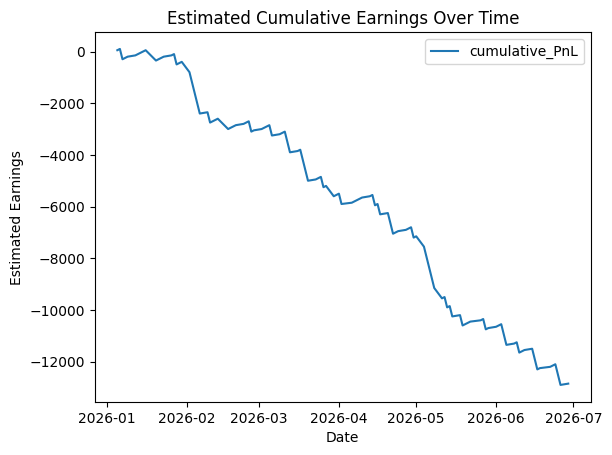

In [ ]:
# Plot Estimated Cumulative Earnings

sns.lineplot(x=df_portfolio_rscv['Date'], y=df_portfolio_rscv['cumulative_PnL'], label='cumulative_PnL')
plt.ylabel('Estimated Earnings')
plt.title("Estimated Cumulative Earnings Over Time")
plt.show()

In [ ]:
# Check the PnL stats of the directional moves
df_portfolio_rscv[['buy_strategy','trade_PnL']].groupby('buy_strategy').sum().reset_index()

Price,buy_strategy,trade_PnL
Ticker,,
0,bear call spread,-5900
1,bull put spread,-6950


# Calibrated Classifier / Platt Scaling

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


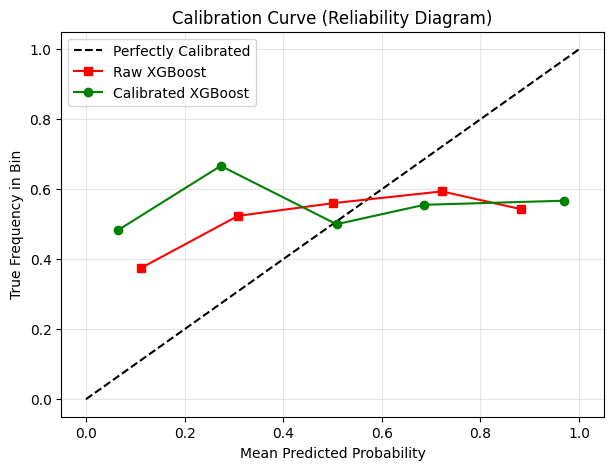

In [ ]:
# Train Calibrated model
calibrated_model = CalibratedClassifierCV(model, method='sigmoid', cv='prefit')
calibrated_model.fit(X_train, y_train)

# Get positive class probabilities
cal_probs = calibrated_model.predict_proba(X_test)[:, 1]

# Generate curve coordinates
true_p_raw, pred_p_raw = calibration_curve(y_test, predicted_proba, n_bins=5)
true_p_cal, pred_p_cal = calibration_curve(y_test, cal_probs, n_bins=5)

# Plot Results
plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
plt.plot(pred_p_raw, true_p_raw, "s-", color="red", label="Raw XGBoost")
plt.plot(pred_p_cal, true_p_cal, "o-", color="green", label="Calibrated XGBoost")

plt.ylabel("True Frequency in Bin")
plt.xlabel("Mean Predicted Probability")
plt.title("Calibration Curve (Reliability Diagram)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

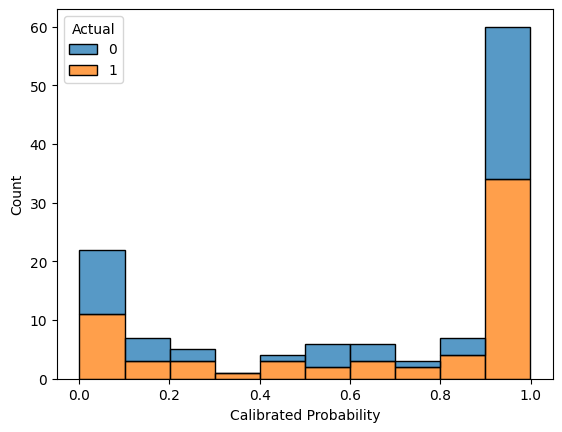

In [ ]:
# Plot histogram for calibrated probability
df_pred = pd.DataFrame({
    'Date': df_portfolio['Date'].reset_index(drop=True),
    'Actual': y_test.reset_index(drop=True),
    'Calibrated Probability': cal_probs})

# Assess the predicted probability distribution
sns.histplot(data=df_pred, x='Calibrated Probability', hue='Actual', bins= 10, multiple='stack')
plt.show()

# EDA to assess distribution of the stock price % changes

In [ ]:
# Initialize new dataframe

ticker = '^SPX'
start_date = '2020-01-01'
end_date = '2025-12-31'
df = yf.download(ticker, start=start_date, end=end_date, interval='1d', auto_adjust=True).reset_index()
df = df.sort_index()
df['% price close'] = (df[('Close', ticker)].shift(-1) - df[('Close', ticker)] ) / df[('Close', ticker)].shift(-1)

df['% price close'].describe()

[*********************100%***********************]  1 of 1 completed


,% price close
count,1506.000000
mean,0.000410
std,0.013286
min,-0.136158
25%,-0.004834
50%,0.000974
75%,0.006828
max,0.086886


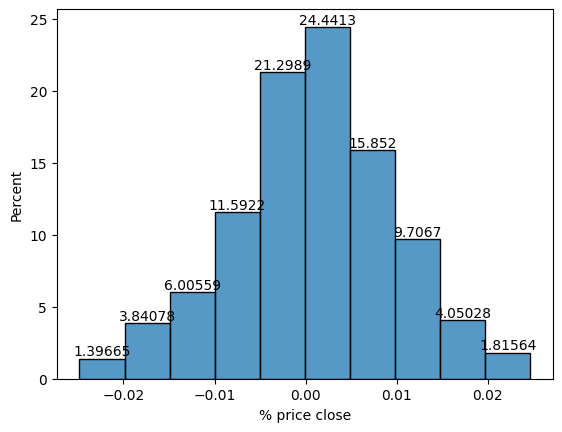

In [ ]:
# Assess the stock price % change distribution for absolute returns <= 5%
df_narrow = df[abs(df['% price close']) <= 0.025].copy()

ax = sns.histplot(data=df_narrow, x='% price close', bins=10, stat='percent')

for container in ax.containers:
    ax.bar_label(container)

plt.show()


In [ ]:
# Assess class proportions
def check_pnt_proportion(row,threshold):
  if row[('% price close','')] < -threshold: x = 0
  elif (row[('% price close','')] >= -threshold) & (row[('% price close','')] < 0): x = 1
  elif (row[('% price close','')] >= 0) & (row[('% price close','')] < threshold): x = 2
  else: x = 3
  return x

df['target_label'] = df.apply(check_pnt_proportion, axis=1, threshold=0.005)
df['target_label'].value_counts()

,count
target_label,
3,477
0,373
2,343
1,314


# Multi Class

In [ ]:
# Feature Engineering and data processing pipeline for multiclass labels

ticker = '^SPX'
start_date = '2020-01-01'
test_start_date = '2026-01-01'
current_date = '2026-06-30'
#current_date = datetime.now().date()
label = 'multi'

X_train_m, y_train_m, X_test_m, y_test_m, df_predict_m, test_date, list_date = prep_data(ticker, start_date, test_start_date, current_date, label)
X_train_m.head()

[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2541/1032760582.py:7: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(columns=['day']) # Drop the original 'day' column
/tmp/ipykernel_2541/1032760582.py:11: PerformanceWarning: indexing past lexsort depth may impact performance.
  df['month'] = df[('Date',)].dt.month
/tmp/ipykernel_2541/1032760582.py:116: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'bb_{j}_period_{i}_std_open_to_lower'] = (df[('Open', ticker)] - df['bb_lower_band'])/df[f'SMA_{j}']
/tmp/ipykernel_2541/1032760582.py:117: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` ma

,day_Monday,day_Thursday,day_Tuesday,day_Wednesday,month,sin_month,cos_month,ratio close to high T0,ratio close to low T0,ratio close to open T0,...,Bearish Marubozu T-2,Spinning_Tops_Doji T0,Spinning_Tops_Doji T-1,Spinning_Tops_Doji T-2,Bullish Hammer T0,Bearish Shooting Star T0,Bullish Harami T0,Bearish Harami T0,Bullish Engulfing T0,Bearish Engulfing T0
0,-0.478554,1.994216,-0.510754,-0.508689,-1.618359,0.719365,1.236998,0.793218,0.015914,0.382086,...,-4.566735,-0.333579,-0.333579,-0.535434,-0.340896,-0.349319,-0.109911,0.0,-0.063203,-0.149576
1,-0.478554,-0.501450,-0.510754,-0.508689,-1.618359,0.719365,1.236998,0.326362,-0.388823,0.239442,...,-4.566735,-0.333579,-0.333579,-0.535434,-0.340896,-0.349319,-0.109911,0.0,-0.063203,-0.149576
2,2.089629,-0.501450,-0.510754,-0.508689,-1.618359,0.719365,1.236998,0.781719,0.410980,0.867357,...,0.218975,-0.333579,-0.333579,-0.535434,-0.340896,-0.349319,-0.109911,0.0,-0.063203,-0.149576
3,-0.478554,-0.501450,1.957890,-0.508689,-1.618359,0.719365,1.236998,0.477593,-0.712595,-0.166869,...,0.218975,-0.333579,-0.333579,-0.535434,-0.340896,-0.349319,-0.109911,0.0,-0.063203,-0.149576
4,-0.478554,-0.501450,-0.510754,1.965837,-1.618359,0.719365,1.236998,0.214835,-0.230677,0.422247,...,0.218975,-0.333579,-0.333579,-0.535434,-0.340896,-0.349319,-0.109911,0.0,-0.063203,-0.149576


In [ ]:
# Train XGB Classifier model

model_m = XGBClassifier(random_state=42
#    n_estimators=100, learning_rate=0.1, max_depth=5,random_state=42
)

# Fit the model
model_m.fit(X_train_m, y_train_m)

# Make train predictions
predictions_m = model_m.predict(X_test_m)
predicted_class_proba = model_m.predict_proba(X_test_m)[np.arange(len(X_test_m)), predictions_m]

t = 0.005
print('---Test Data---')
print(y_test_m.value_counts())
print(f'Accuracy Score : {accuracy_score(y_test_m, predictions_m)}')
print(f'Precision Score : {precision_score(y_test_m, predictions_m, average='macro')}')
print(f'Recall Score : {recall_score(y_test_m, predictions_m, average='macro')}')
print('--- Confusion Matrix ---')
print(confusion_matrix(y_test_m, predictions_m))
print('--- Classification Report ---')
print(classification_report(y_test_m, predictions_m, target_names=[f"x<-{t}", f"-{t}<=x<0", f"0<x<{t}", f"x>={t}"]))


---Test Data---
cat_close
3    41
1    29
0    26
2    25
Name: count, dtype: int64
Accuracy Score : 0.2809917355371901
Precision Score : 0.25988312534922703
Recall Score : 0.25528013197903865
--- Confusion Matrix ---
[[ 3  2  7 14]
 [ 4  4  9 12]
 [ 2  3  7 13]
 [12  4  5 20]]
--- Classification Report ---
              precision    recall  f1-score   support

    x<-0.005       0.14      0.12      0.13        26
 -0.005<=x<0       0.31      0.14      0.19        29
   0<x<0.005       0.25      0.28      0.26        25
    x>=0.005       0.34      0.49      0.40        41

    accuracy                           0.28       121
   macro avg       0.26      0.26      0.25       121
weighted avg       0.27      0.28      0.26       121



Match
0    87
1    34
Name: count, dtype: int64


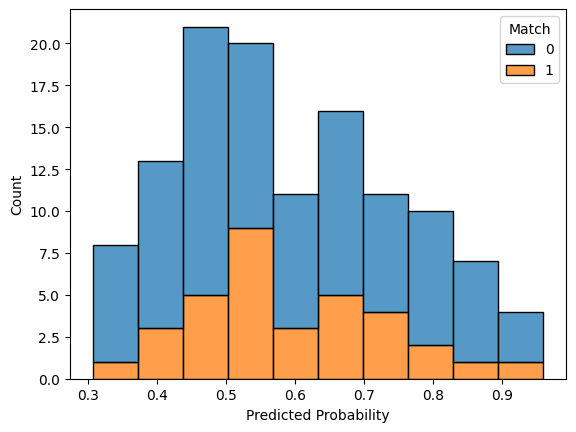

In [ ]:
# Create dataframe to plot histogram of predicted probability
df_pred = pd.DataFrame({
    'Date': test_date,
    'Actual': y_test_m,
    'Predicted': predictions_m,
    'Predicted Probability': predicted_class_proba})

df_pred['Match'] = np.where(df_pred['Actual'] == df_pred['Predicted'],1,0)
print(df_pred['Match'].value_counts())

# Assess the predicted probability distribution
sns.histplot(data=df_pred, x='Predicted Probability', hue='Match', bins= 10, multiple='stack')

plt.show()

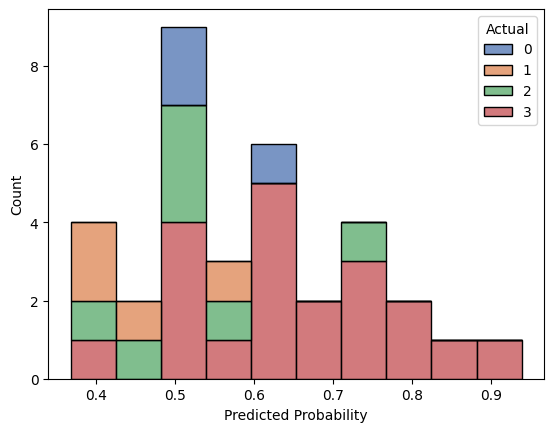

In [ ]:
# Assess the predicted probability distribution for correct predictions
df_pred_m = df_pred[df_pred['Match'] == 1].copy()
sns.histplot(data=df_pred_m, x='Predicted Probability', hue='Actual', bins= 10, multiple='stack', palette = 'deep')
plt.show()

# PnL Assessment 1

In [ ]:
# Create dataframe for multiclass labels

df_test_orig_m = yf.download(ticker, start= '2025-12-01', end='2026-06-30', interval='1d', auto_adjust=True).reset_index()
df_test_orig_m = df_test_orig_m[df_test_orig_m['Date'] >= '2026-01-01'].iloc[1:].copy()
df_test_orig_m['predicted_direction'] = predictions_m
df_test_orig_m['actual_direction'] = list(y_test_m)
df_test_orig_m.head(10)

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume,predicted_direction,actual_direction
Ticker,,^SPX,^SPX,^SPX,^SPX,^SPX,,
23,2026-01-05,6902.049805,6920.379883,6891.560059,6892.189941,5771930000,3,3
24,2026-01-06,6944.819824,6948.689941,6904.020020,6908.029785,5509680000,2,3
25,2026-01-07,6920.930176,6965.689941,6919.189941,6945.069824,5214480000,2,1
26,2026-01-08,6921.459961,6931.279785,6899.330078,6914.109863,5333200000,2,2
27,2026-01-09,6966.279785,6978.359863,6917.640137,6927.830078,5163900000,3,3
28,2026-01-12,6977.270020,6986.330078,6934.069824,6944.120117,5019040000,3,2
29,2026-01-13,6963.740234,6985.830078,6938.770020,6977.410156,5091730000,2,1
30,2026-01-14,6926.600098,6941.299805,6885.740234,6937.410156,5530830000,0,0
31,2026-01-15,6944.470215,6979.339844,6937.930176,6969.459961,5114050000,3,2


In [ ]:
# Assess Portfolio earnings based on multiclass labels

def calculate_portfolio_returns_m(df):
  df['buy_strategy'] = np.where(((df['predicted_direction'] == 2) | (df['predicted_direction'] == 3)), 'bull put spread', 'bear call spread')
  df['entry_level'] = np.where(df['buy_strategy'] == 'bull put spread', (df[('Open', ticker)] - 20) // 5 * 5, 0)
  df['entry_level'] = np.where(df['buy_strategy'] == 'bear call spread', (df[('Open', ticker)] + 20) // 5 * 5, df['entry_level'])

  df['trade_PnL'] = np.where((df['buy_strategy'] == 'bull put spread') & (df['entry_level'] <= (df[('Close', ticker)])), 50, 0)
  df['trade_PnL'] = np.where((df['buy_strategy'] == 'bull put spread') & (df['entry_level'] > (df[('Close', ticker)])), -400, df['trade_PnL'])
  df['trade_PnL'] = np.where((df['buy_strategy'] == 'bear call spread') & (df['entry_level'] >= (df[('Close', ticker)])), 50, df['trade_PnL'])
  df['trade_PnL'] = np.where((df['buy_strategy'] == 'bear call spread') & (df['entry_level'] < (df[('Close', ticker)])), -400, df['trade_PnL'])

  df['cumulative_PnL'] = df['trade_PnL'].cumsum()

  return df
df_portfolio_m = calculate_portfolio_returns_m(df_test_orig_m.copy())
df_portfolio_m.tail()

Price,Date,Close,High,Low,Open,Volume,predicted_direction,actual_direction,buy_strategy,entry_level,trade_PnL,cumulative_PnL
Ticker,,^SPX,^SPX,^SPX,^SPX,^SPX,,,,,,
139,2026-06-23,7365.459961,7424.169922,7347.600098,7366.509766,5640530000,3,0,bull put spread,7345.0,50,-13950
140,2026-06-24,7358.220215,7428.060059,7336.819824,7370.879883,5994860000,3,1,bull put spread,7350.0,50,-13900
141,2026-06-25,7357.490234,7419.080078,7323.500000,7404.910156,5565760000,3,1,bull put spread,7380.0,-400,-14300
142,2026-06-26,7354.020020,7392.950195,7294.180176,7312.740234,9105600000,1,1,bear call spread,7330.0,-400,-14700
143,2026-06-29,7440.430176,7444.319824,7348.879883,7391.879883,5794570000,3,3,bull put spread,7370.0,50,-14650


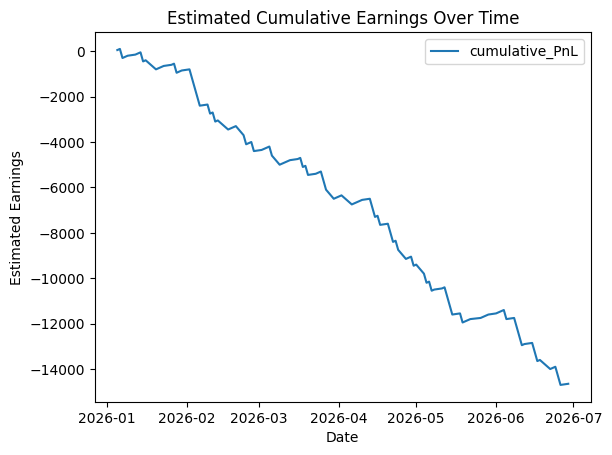

In [ ]:
# Plot Estimated Cumulative Earnings

sns.lineplot(x=df_portfolio_m['Date'], y=df_portfolio_m['cumulative_PnL'], label='cumulative_PnL')
plt.ylabel('Estimated Earnings')
plt.title("Estimated Cumulative Earnings Over Time")
plt.show()

In [ ]:
# Check the PnL stats of the directional moves
df_portfolio_m[['buy_strategy','trade_PnL']].groupby('buy_strategy').sum().reset_index()

Price,buy_strategy,trade_PnL
Ticker,,
0,bear call spread,-6400
1,bull put spread,-8250


# PnL Assessment 2

In [ ]:
df_test_orig_m_1 = yf.download(ticker, start= '2025-12-01', end='2026-06-30', interval='1d', auto_adjust=True).reset_index()
df_test_orig_m_1['prev_close'] = df_test_orig_m_1[('Close', ticker)].shift(1)
df_test_orig_m_1 = df_test_orig_m_1[df_test_orig_m_1['Date'] >= '2026-01-01'].iloc[1:].copy()
df_test_orig_m_1['predicted_direction'] = predictions_m
df_test_orig_m_1['actual_direction'] = list(y_test_m)

df_test_orig_m_1.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume,prev_close,predicted_direction,actual_direction
Ticker,,^SPX,^SPX,^SPX,^SPX,^SPX,,,
23,2026-01-05,6902.049805,6920.379883,6891.560059,6892.189941,5771930000,6858.470215,3,3
24,2026-01-06,6944.819824,6948.689941,6904.020020,6908.029785,5509680000,6902.049805,2,3
25,2026-01-07,6920.930176,6965.689941,6919.189941,6945.069824,5214480000,6944.819824,2,1
26,2026-01-08,6921.459961,6931.279785,6899.330078,6914.109863,5333200000,6920.930176,2,2
27,2026-01-09,6966.279785,6978.359863,6917.640137,6927.830078,5163900000,6921.459961,3,3


In [ ]:
# What if we adjust the entry positions slightly to suit the multiclass labels?

def calculate_portfolio_returns_m1(df):
  df['buy_strategy'] = np.where(((df['predicted_direction'] == 2) | (df['predicted_direction'] == 3)), 'bull put spread', 'bear call spread')
  df['entry_level'] = np.where(df['predicted_direction'] == 3, (df[('Open', ticker)] - 20) // 5 * 5, 0)
  df['entry_level'] = np.where(df['predicted_direction'] == 2, (df[('Open', ticker)] - 0.005*df['prev_close'] - 20) // 5 * 5, df['entry_level'])
  df['entry_level'] = np.where(df['predicted_direction'] == 1, (df[('Open', ticker)] + 0.005*df['prev_close'] + 20) // 5 * 5, df['entry_level'])
  df['entry_level'] = np.where(df['predicted_direction'] == 0, (df[('Open', ticker)] + 20) // 5 * 5, df['entry_level'])

  df['trade_PnL'] = np.where((df['buy_strategy'] == 'bull put spread') & (df['entry_level'] <= (df[('Close', ticker)])), 50, 0)
  df['trade_PnL'] = np.where((df['buy_strategy'] == 'bull put spread') & (df['entry_level'] > (df[('Close', ticker)])), -400, df['trade_PnL'])
  df['trade_PnL'] = np.where((df['buy_strategy'] == 'bear call spread') & (df['entry_level'] >= (df[('Close', ticker)])), 50, df['trade_PnL'])
  df['trade_PnL'] = np.where((df['buy_strategy'] == 'bear call spread') & (df['entry_level'] < (df[('Close', ticker)])), -400, df['trade_PnL'])

  df['cumulative_PnL'] = df['trade_PnL'].cumsum()

  return df

df_portfolio_m_1 = calculate_portfolio_returns_m1(df_test_orig_m_1.copy())
df_portfolio_m_1.tail()

Price,Date,Close,High,Low,Open,Volume,prev_close,predicted_direction,actual_direction,buy_strategy,entry_level,trade_PnL,cumulative_PnL
Ticker,,^SPX,^SPX,^SPX,^SPX,^SPX,,,,,,,
139,2026-06-23,7365.459961,7424.169922,7347.600098,7366.509766,5640530000,7472.790039,3,0,bull put spread,7345.0,50,-8100
140,2026-06-24,7358.220215,7428.060059,7336.819824,7370.879883,5994860000,7365.459961,3,1,bull put spread,7350.0,50,-8050
141,2026-06-25,7357.490234,7419.080078,7323.500000,7404.910156,5565760000,7358.220215,3,1,bull put spread,7380.0,-400,-8450
142,2026-06-26,7354.020020,7392.950195,7294.180176,7312.740234,9105600000,7357.490234,1,1,bear call spread,7365.0,50,-8400
143,2026-06-29,7440.430176,7444.319824,7348.879883,7391.879883,5794570000,7354.020020,3,3,bull put spread,7370.0,50,-8350


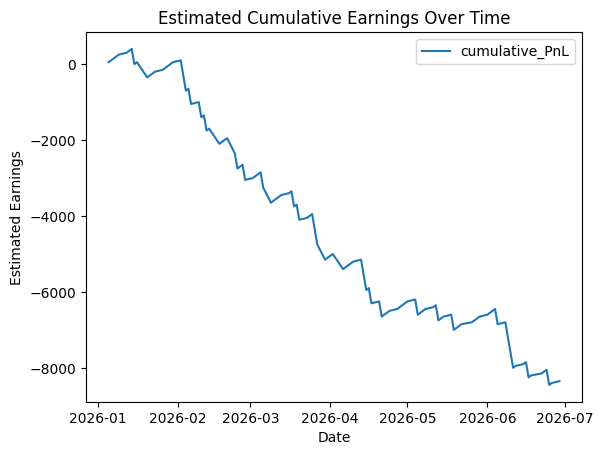

In [ ]:
# Plot Estimated Cumulative Earnings

sns.lineplot(x=df_portfolio_m_1['Date'], y=df_portfolio_m_1['cumulative_PnL'], label='cumulative_PnL')
plt.ylabel('Estimated Earnings')
plt.title("Estimated Cumulative Earnings Over Time")
plt.show()

In [ ]:
# Check the PnL stats of the directional moves
df_portfolio_m_1[['buy_strategy','trade_PnL']].groupby('buy_strategy').sum().reset_index()

Price,buy_strategy,trade_PnL
Ticker,,
0,bear call spread,-3700
1,bull put spread,-4650


# Perform Hyperparameter tuning via RandomSearchCV

In [ ]:
# Define the parameter search space
# Using statistical distributions ensures smooth random sampling across bounds
param_dist = {
    "n_estimators": randint(100, 1000),         # Number of trees
    "learning_rate": uniform(0.01, 0.25),        # Step size shrinkage
    "max_depth": randint(3, 10),                 # Tree depth complexity
    "min_child_weight": randint(1, 10),          # Noise control
    "subsample": uniform(0.6, 0.4),              # Row fraction sampling (0.6 to 1.0)
    "colsample_bytree": uniform(0.6, 0.4),       # Feature fraction sampling (0.6 to 1.0)
    "gamma": uniform(0, 5)                       # Split threshold penalty
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,                  # Number of random combinations evaluated
    scoring="accuracy",          # Metric to optimize
    verbose=1,
    random_state=42,
    n_jobs=-1,
    return_train_score=False
)

# 5. Execute the search
print("Starting hyperparameter tuning space search...")
random_search.fit(X_train_m, y_train_m)

# 6. Extract winning configurations
print(f"\nBest Score: {random_search.best_score_:.4f}")
print("Best Parameters Discovered:")
for param_name, param_value in random_search.best_params_.items():
    print(f" -> {param_name}: {param_value}")

# Fetching the optimized model directly
xgb_m_rscv = random_search.best_estimator_

Starting hyperparameter tuning space search...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Score: 0.3295
Best Parameters Discovered:
 -> colsample_bytree: 0.749816047538945
 -> gamma: 4.75357153204958
 -> learning_rate: 0.19299848545285128
 -> max_depth: 7
 -> min_child_weight: 5
 -> n_estimators: 714
 -> subsample: 0.7783331011414365


In [ ]:
print(random_search.best_params_)

{'colsample_bytree': 0.749816047538945, 'gamma': 4.75357153204958, 'learning_rate': 0.19299848545285128, 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 714, 'subsample': 0.7783331011414365}


In [ ]:
# Train XGB with random search CV parameters
rscv_params_m = {'colsample_bytree': 0.749816047538945, 'gamma': 4.75357153204958, 'learning_rate': 0.19299848545285128, 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 714, 'subsample': 0.7783331011414365}
xgb_rscv_m = XGBClassifier(random_state=42, **rscv_params_m)
xgb_rscv_m.fit(X_train_m, y_train_m)

# Make train predictions
predictions_rscv_m = xgb_rscv_m.predict(X_test_m)
predicted_rscv_class_proba = xgb_rscv_m.predict_proba(X_test_m)[np.arange(len(X_test_m)), predictions_rscv_m]

t = 0.005
print('---Test Data---')
print(f'Accuracy Score : {accuracy_score(y_test_m, predictions_rscv_m)}')
print(f'Precision Score : {precision_score(y_test_m, predictions_rscv_m, average='macro')}')
print(f'Recall Score : {recall_score(y_test_m, predictions_rscv_m, average='macro')}')
print('--- Confusion Matrix ---')
print(confusion_matrix(y_test_m, predictions_rscv_m))
print('--- Classification Report ---')
print(classification_report(y_test_m, predictions_rscv_m, target_names=[f"x<-{t}", f"-{t}<=x<0", f"0<x<{t}", f"x>={t}"]))


---Test Data---
Accuracy Score : 0.24793388429752067
Precision Score : 0.20606060606060606
Recall Score : 0.2268383256776865
--- Confusion Matrix ---
[[ 4  1  4 17]
 [ 5  1 12 11]
 [ 1  3  7 14]
 [10  6  7 18]]
--- Classification Report ---
              precision    recall  f1-score   support

    x<-0.005       0.20      0.15      0.17        26
 -0.005<=x<0       0.09      0.03      0.05        29
   0<x<0.005       0.23      0.28      0.25        25
    x>=0.005       0.30      0.44      0.36        41

    accuracy                           0.25       121
   macro avg       0.21      0.23      0.21       121
weighted avg       0.21      0.25      0.22       121



In [ ]:
# Recreate dataframe for PnL computation of tuned XGB model

df_test_orig_rscv_m = yf.download(ticker, start= '2025-12-01', end='2026-06-30', interval='1d', auto_adjust=True).reset_index()
df_test_orig_rscv_m = df_test_orig_rscv_m[df_test_orig_rscv_m['Date'] >= '2026-01-01'].iloc[1:].copy()
df_test_orig_rscv_m['predicted_direction'] = predictions_rscv_m
df_test_orig_rscv_m['actual_direction'] = list(y_test_m)

df_portfolio_rscv_m = calculate_portfolio_returns_m(df_test_orig_rscv_m.copy())
df_portfolio_rscv_m.tail()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume,predicted_direction,actual_direction,buy_strategy,entry_level,trade_PnL,cumulative_PnL
Ticker,,^SPX,^SPX,^SPX,^SPX,^SPX,,,,,,
139,2026-06-23,7365.459961,7424.169922,7347.600098,7366.509766,5640530000,3,0,bull put spread,7345.0,50,-13050
140,2026-06-24,7358.220215,7428.060059,7336.819824,7370.879883,5994860000,3,1,bull put spread,7350.0,50,-13000
141,2026-06-25,7357.490234,7419.080078,7323.500000,7404.910156,5565760000,3,1,bull put spread,7380.0,-400,-13400
142,2026-06-26,7354.020020,7392.950195,7294.180176,7312.740234,9105600000,3,1,bull put spread,7290.0,50,-13350
143,2026-06-29,7440.430176,7444.319824,7348.879883,7391.879883,5794570000,3,3,bull put spread,7370.0,50,-13300


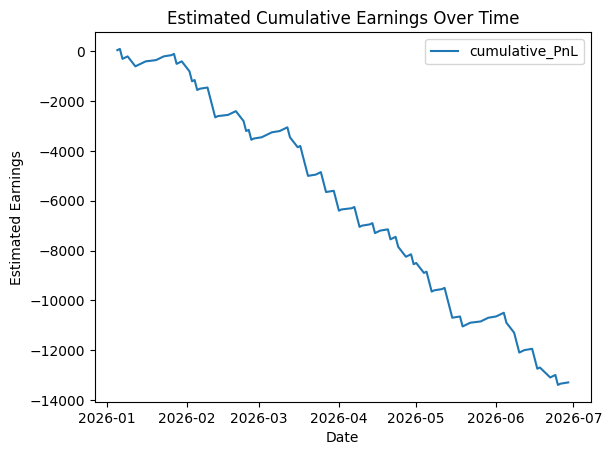

In [ ]:
# Plot Estimated Cumulative Earnings

sns.lineplot(x=df_portfolio_rscv_m['Date'], y=df_portfolio_rscv_m['cumulative_PnL'], label='cumulative_PnL')
plt.ylabel('Estimated Earnings')
plt.title("Estimated Cumulative Earnings Over Time")
plt.show()

In [ ]:
# Check the PnL stats of the directional moves
df_portfolio_rscv_m[['buy_strategy','trade_PnL']].groupby('buy_strategy').sum().reset_index()

Price,buy_strategy,trade_PnL
Ticker,,
0,bear call spread,-5650
1,bull put spread,-7650


# Calibrated Classifier / Platt Scaling for Multi Class Labels

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


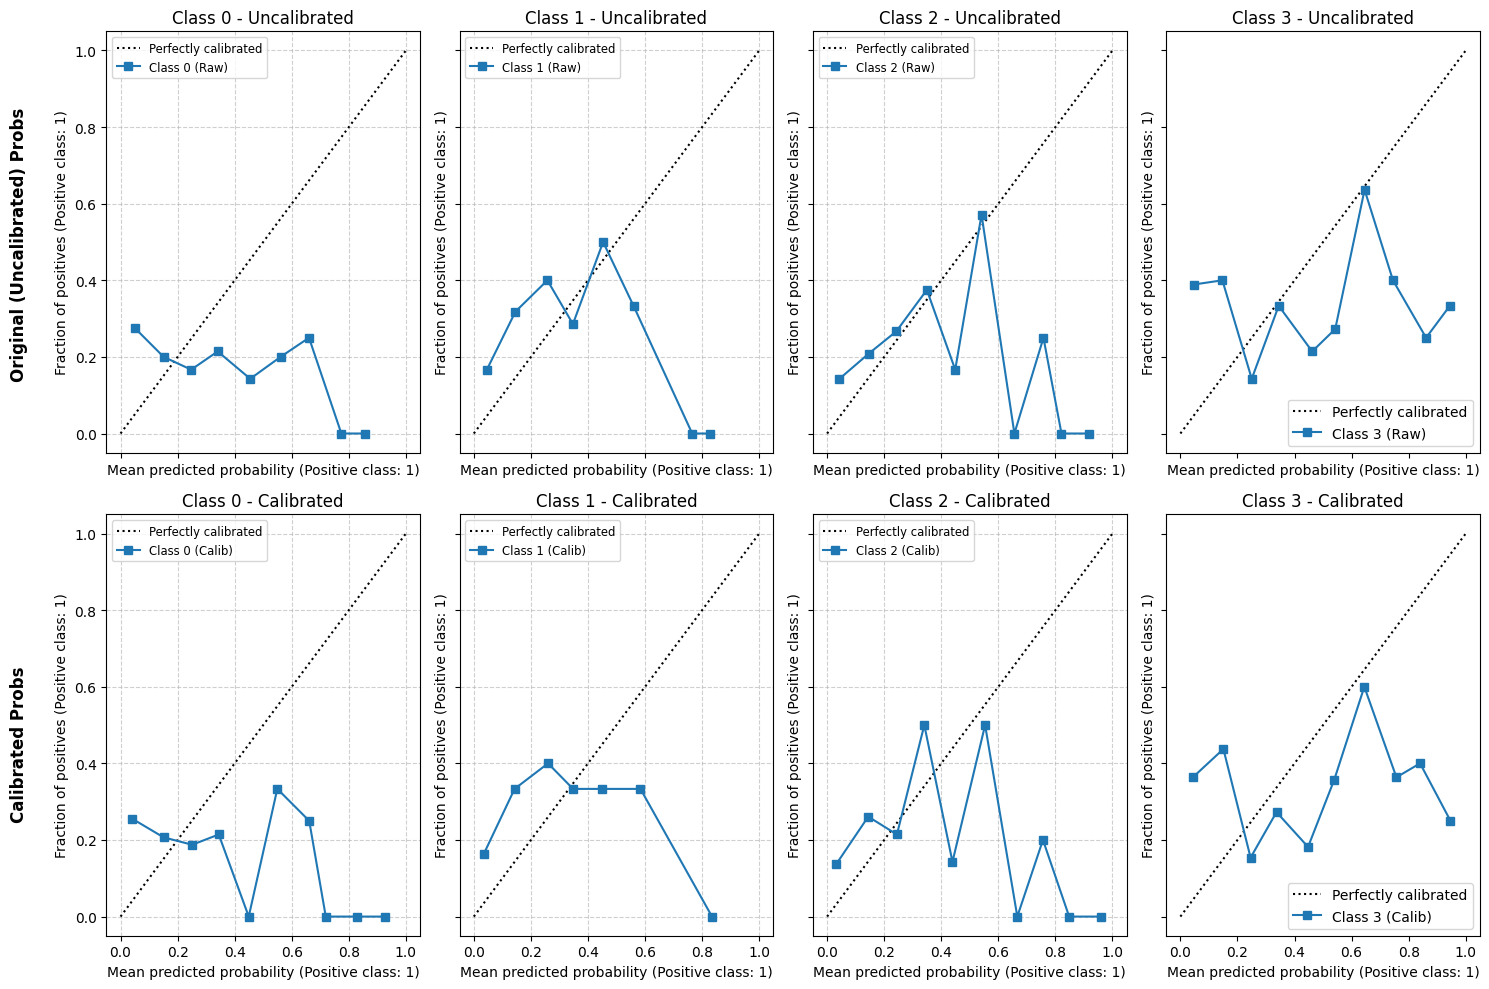

In [ ]:
# Train Calibrated model for multiclass labels

calibrated_model_m = CalibratedClassifierCV(estimator=model_m, method='isotonic', cv='prefit')
calibrated_model_m.fit(X_train_m, y_train_m)

# Predict probabilities on unseen test data
uncalib_probs_m = model_m.predict_proba(X_test_m)
calib_probs_m = calibrated_model_m.predict_proba(X_test_m)

# Plot

# sharex and sharey keep the scales identical across all subplots for easy comparison
fig, axes = plt.subplots(nrows=2, ncols=y_test_m.nunique(), figsize=(15, 10), sharex=True, sharey=True)

# 2. Define the titles for our rows to keep the plots clean
row_titles = ["Original (Uncalibrated) Probs", "Calibrated Probs"]

for i in range(y_test_m.nunique()):
    # Create binary true labels for the specific class i (One-vs-Rest)
    y_test_bin = (y_test_m == i).astype(int)

    # Original Uncalibrated Probabilities
    CalibrationDisplay.from_predictions(
        y_test_bin,
        uncalib_probs_m[:, i],
        n_bins=10,
        name=f"Class {i} (Raw)",
        ax=axes[0, i]
    )
    axes[0, i].set_title(f"Class {i} - Uncalibrated")

    # Calibrated Probabilities
    CalibrationDisplay.from_predictions(
        y_test_bin,
        calib_probs_m[:, i],
        n_bins=10,
        name=f"Class {i} (Calib)",
        ax=axes[1, i]
    )
    axes[1, i].set_title(f"Class {i} - Calibrated")

# 3. Polish the layout: Move legends to top-left and add row labels
for row_idx in range(2):
    for col_idx in range(3):
        ax = axes[row_idx, col_idx]

        # Shift legend to the top left corner
        # 'loc' handles positioning, 'frameon=True' adds a subtle background box
        ax.legend(loc="upper left", frameon=True, fontsize='small')

        # Add grid lines to make tracking deviation from the 45-degree line easier
        ax.grid(True, linestyle="--", alpha=0.6)

# Add overarching row identifiers on the far left edge
fig.text(0.01, 0.75, row_titles[0], va='center', rotation='vertical', weight='bold', fontsize=12)
fig.text(0.01, 0.25, row_titles[1], va='center', rotation='vertical', weight='bold', fontsize=12)

plt.tight_layout(rect=[0.03, 0, 1, 1]) # Make room for the left-side text labels
plt.show()